# Grassroots Tournament Scenes: League of Legends vs. Counter-Strike vs. Dota 2

**Purpose:** extends `grassroots_scene_comparison.ipynb`'s Counter-Strike/Dota 2
grassroots comparison to a third title for the first time — League of
Legends — made possible only by `collectors/liquipedia_lpdb.py` (built
2026-09-30, `docs/liquipedia_lpdb_transition_plan.md` Phase 1). `tournaments`
(the MediaWiki-sourced table) has **zero** B/C-Tier League of Legends rows:
no grassroots crawl was ever built for this title (`collectors/
liquipedia_grassroots.py` only ever targeted Counter-Strike and Dota 2).
League's grassroots scene is genuinely invisible to this project without
LPDB — this notebook is the first time it exists here at all.

Built on `tournaments_lpdb`, not `tournaments`, for **all three** titles —
not just League — so every comparison below uses one consistent source and
methodology rather than mixing two differently-shaped collectors. See
`docs/liquipedia_lpdb_transition_plan.md`'s Phase 2 reconciliation
(2026-09-30) for why this is safe to do now for these three titles
specifically (near-total page overlap with `tournaments` once a page-name
formatting mismatch is normalized, cleaner tier/date data) without waiting
for the other 19 tracked titles' first LPDB pull.

Grassroots here means LPDB's own clean `tier IN ('3','4')` — no letter-grade
normalization needed, unlike `tournaments.tier`'s messy S/A/B/C-Tier mix
(see the transition plan's own finding on this). League of Legends
additionally has a **tier 5** in LPDB (school/collegiate-level events like
"LJL Challenger Tournament" and "Irish Collegiate Esports Winter Series")
that Counter-Strike and Dota 2 don't have at all — excluded from the
"grassroots" definition here to keep the three-way comparison on equal
footing, noted but not analyzed further.

In [1]:
# Imports and repo path setup -- same pattern as grassroots_scene_comparison.ipynb.
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from etl.db import get_connection

conn = get_connection()
plt.rcParams["figure.dpi"] = 110

# Partition logic -- ONE rule for all three titles, unlike the original
# CS/Dota2 notebook's per-title rule, because tournaments_lpdb.tier is
# already clean and uniform across every wiki tested (no letter-grade
# normalization needed).
GRASSROOTS = "tier IN ('3','4')"
TIER12 = "tier IN ('1','2')"

TITLES = [
    ("league_of_legends", "#2ca02c", "League of Legends"),
    ("counter_strike", "#ff7f0e", "Counter-Strike"),
    ("dota2", "#1f77b4", "Dota 2"),
]

## 1. Data coverage and partition method

Same standing rule as `grassroots_scene_comparison.ipynb` §1: check every
field's real coverage before charting any of it.

In [2]:
rows = []
for title_id, _, label in TITLES:
    total = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS}", conn, params=(title_id,)).iloc[0]["n"]
    with_date = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND start_date GLOB '[0-9][0-9][0-9][0-9]-*'", conn, params=(title_id,)).iloc[0]["n"]
    with_region = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND region IS NOT NULL", conn, params=(title_id,)).iloc[0]["n"]
    with_country = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND country IS NOT NULL", conn, params=(title_id,)).iloc[0]["n"]
    with_prize_nonzero = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND prize_pool>0", conn, params=(title_id,)).iloc[0]["n"]
    with_team = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND team_number IS NOT NULL AND team_number>=0", conn, params=(title_id,)).iloc[0]["n"]
    team_sentinel = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND team_number<0", conn, params=(title_id,)).iloc[0]["n"]
    rows.append({
        "title": label, "total_pages": total,
        "start_date_parseable": f"{with_date}/{total} ({with_date/total:.0%})",
        "region_populated": f"{with_region}/{total} ({with_region/total:.0%})",
        "country_populated": f"{with_country}/{total} ({with_country/total:.0%})",
        "prize_pool_gt_zero": f"{with_prize_nonzero}/{total} ({with_prize_nonzero/total:.0%})",
        "team_number_usable": f"{with_team}/{total} ({with_team/total:.0%})",
        "team_number_sentinel_neg1": f"{team_sentinel} ({team_sentinel/total:.0%})",
    })
coverage_df = pd.DataFrame(rows).set_index("title").T
print(coverage_df.to_string())

title                     League of Legends      Counter-Strike            Dota 2
total_pages                            2485               18196              3035
start_date_parseable        2441/2485 (98%)  18127/18196 (100%)  3023/3035 (100%)
region_populated            2386/2485 (96%)  18156/18196 (100%)   2916/3035 (96%)
country_populated           2128/2485 (86%)    9659/18196 (53%)   1155/3035 (38%)
prize_pool_gt_zero          1176/2485 (47%)   10730/18196 (59%)   2334/3035 (77%)
team_number_usable          2045/2485 (82%)   16301/18196 (90%)   2922/3035 (96%)
team_number_sentinel_neg1         440 (18%)          1895 (10%)          113 (4%)


**Read**: League of Legends' grassroots scene is real and substantial —
2,485 pages, smaller than Counter-Strike's 18,196 but larger than Dota 2's
3,035. Coverage is strong across the board: `start_date` is parseable for
96-100% of rows in every title (a structural improvement over
`tournaments`' wikitext-parsed dates, which needed the NULL-heavy workaround
`grassroots_scene_comparison.ipynb` §1 documented). `prize_pool` is
*technically* populated for 100% of rows in `tournaments_lpdb` (LPDB returns
`0`, not `NULL`, for "no prize") — the meaningful figure is `prize_pool > 0`,
shown here instead: 47% (League), 59% (Counter-Strike), 77% (Dota 2).

**A new sentinel value found, not previously documented in this project**:
`team_number` carries a real `-1` "unknown" sentinel on a meaningful share
of rows — 18% (League), 10% (Counter-Strike), 4% (Dota 2) — the same
pattern already found and handled for `start_date`'s `"0000-01-01"`
sentinel (`collectors/liquipedia_lpdb.py`'s `LPDB_NULL_DATE`
normalization). Not yet normalized at the collector level for
`team_number` — every query below filters `team_number >= 0` by hand
instead; worth promoting to a proper normalizer alongside the existing date
one if this field sees more use.

`country` is a clean, genuine ISO-2 code in `tournaments_lpdb` (confirmed:
0% of populated `country` values here are a broad region like `"Europe"`,
unlike `tournaments.country`, which mixes real countries and broad regions
in the same field — see the `title_geography_maps` report's own finding on
this). But it's populated far less consistently than `region`: 86% (League)
vs. 53% (Counter-Strike) vs. 38% (Dota 2) — §5 below uses both fields for
this reason, same as the original notebook.

## 2. The currency gap — checked directly, not assumed

`grassroots_scene_comparison.ipynb` §1 ran a currency-contamination check
against `tournaments.currency` and found it clean (every populated prize
figure was an explicitly-tagged `'USD'` row). **That check cannot be
repeated here**: `tournaments_lpdb.currency` is `NULL` on every single row,
by construction — confirmed in Phase 0's probe and reconfirmed on all
39,140 rows pulled so far (see `docs/liquipedia_lpdb_transition_plan.md`
Phase 2). Every `prize_pool` figure in this notebook is **nominal face
value in whatever currency LPDB's own `prizepool` field reports** — not
currency-filtered, not verified USD-only.

How much does this actually matter? Checked by joining back to
`tournaments.currency` for the subset of grassroots tournaments that exist
in **both** sources — only meaningfully possible for Counter-Strike and
Dota 2, which already had a dedicated MediaWiki-sourced grassroots crawl.

In [3]:
for title_id, _, label in TITLES:
    lp = {r.liquipedia_page.replace("_", " "): r.prize_pool for r in pd.read_sql_query(
        f"SELECT liquipedia_page, prize_pool FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND prize_pool>0",
        conn, params=(title_id,)).itertuples()}
    mw_currency = {r.liquipedia_page: r.currency for r in pd.read_sql_query(
        "SELECT liquipedia_page, currency FROM tournaments WHERE title_id=?", conn, params=(title_id,)).itertuples()}
    matched = set(lp) & set(mw_currency)
    match_rate = len(matched) / len(lp) if lp else 0
    print(f"{label}: {len(lp)} LPDB grassroots prize-bearing rows, {len(matched)} ({match_rate:.0%}) matched to `tournaments`")
    if matched:
        usd_or_null = sum(1 for p in matched if mw_currency[p] in (None, "USD"))
        non_usd = len(matched) - usd_or_null
        print(f"  of matched: USD-or-null={usd_or_null} ({usd_or_null/len(matched):.0%}), non-USD={non_usd} ({non_usd/len(matched):.0%})")
    else:
        print("  no cross-check possible -- this title has no MediaWiki-sourced grassroots data to compare against")
    print()

League of Legends: 1176 LPDB grassroots prize-bearing rows, 0 (0%) matched to `tournaments`
  no cross-check possible -- this title has no MediaWiki-sourced grassroots data to compare against

Counter-Strike: 10730 LPDB grassroots prize-bearing rows, 10684 (100%) matched to `tournaments`
  of matched: USD-or-null=9021 (84%), non-USD=1663 (16%)

Dota 2: 2334 LPDB grassroots prize-bearing rows, 2318 (99%) matched to `tournaments`
  of matched: USD-or-null=1511 (65%), non-USD=807 (35%)



**Read**: for Counter-Strike and Dota 2, the cross-check is almost fully
possible (100%/99% of LPDB's prize-bearing grassroots rows have a
`tournaments` counterpart, since `collectors/liquipedia_grassroots.py`
already crawled both) — and it shows the currency gap is real, not
negligible: **16% of matched Counter-Strike rows and 35% of matched Dota 2
rows are a non-USD currency**. Naively summing `tournaments_lpdb.prize_pool`
for these two titles mixes a meaningful share of rubles, reais, złoty, and
others in with dollars at face value. **For League of Legends, zero
cross-check is possible** — none of its 2,485 grassroots rows exist in
`tournaments` at all, so there is no independent signal on how much of its
nominal prize total is actually non-USD. Treat every prize-pool figure
below — especially League's — as directional, not currency-clean.

## 3. Tournament count over time

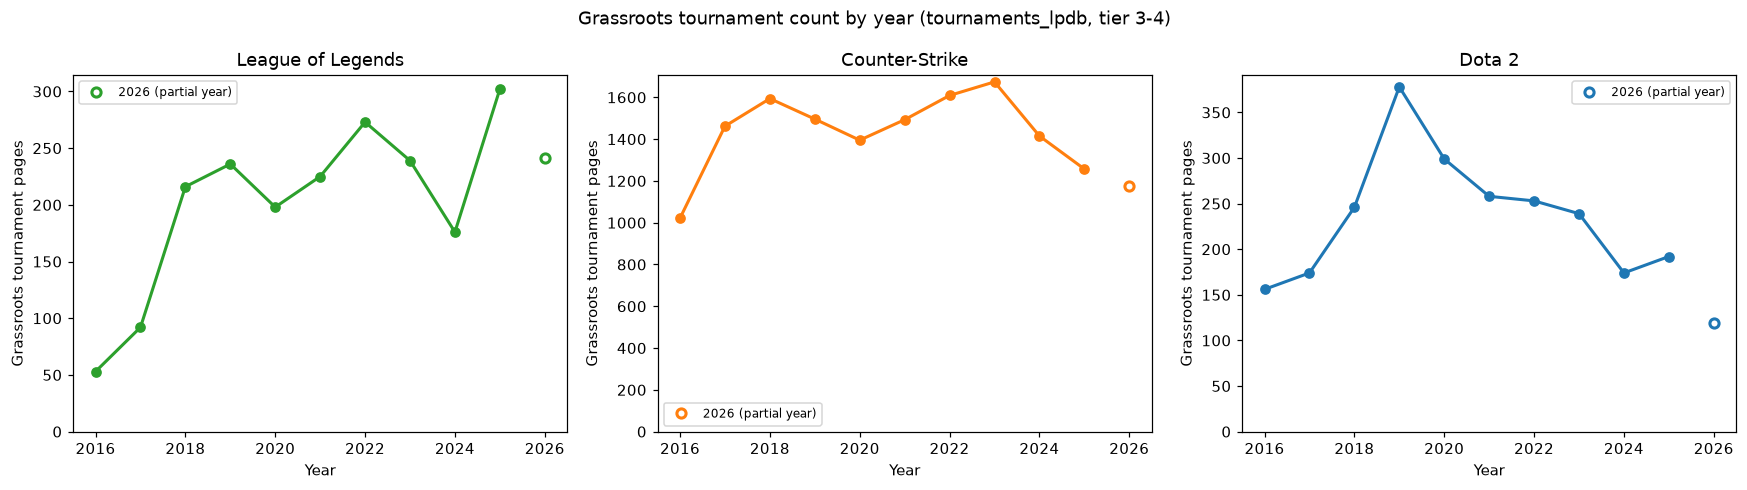

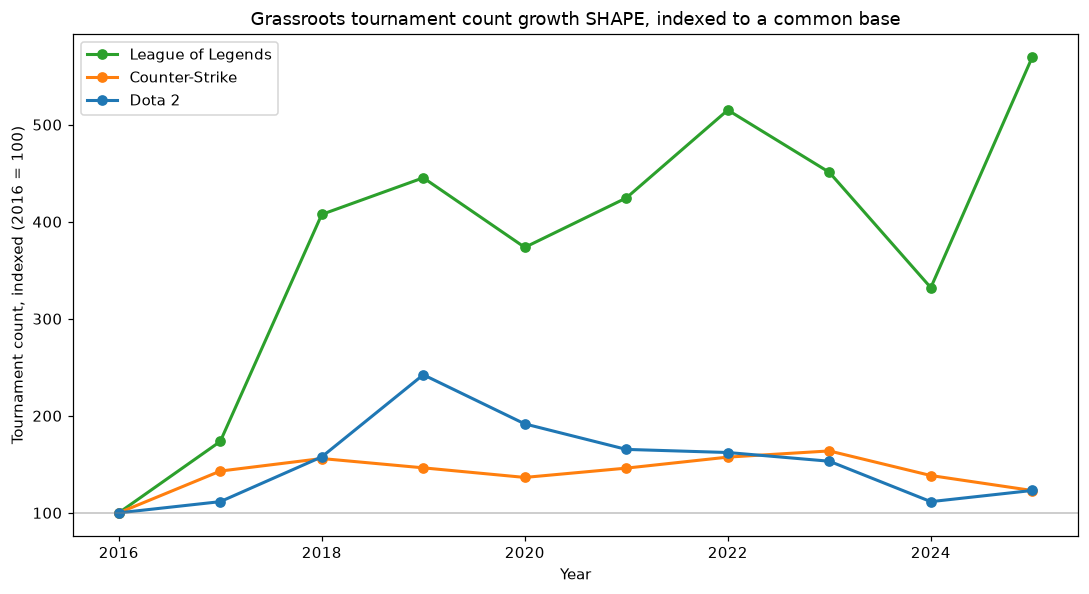


League of Legends:
  yr   n
2016  53
2017  92
2018 216
2019 236
2020 198
2021 225
2022 273
2023 239
2024 176
2025 302
2026 241

Counter-Strike:
  yr    n
2016 1022
2017 1462
2018 1594
2019 1496
2020 1395
2021 1493
2022 1609
2023 1674
2024 1415
2025 1257
2026 1177

Dota 2:
  yr   n
2016 156
2017 174
2018 246
2019 378
2020 299
2021 258
2022 253
2023 239
2024 174
2025 192
2026 119


In [4]:
def yearly_counts(title_id):
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, count(*) AS n FROM tournaments_lpdb "
        f"WHERE title_id=? AND {GRASSROOTS} AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' GROUP BY yr ORDER BY yr",
        conn, params=(title_id,))
    df["yr"] = df["yr"].astype(int)
    return df

count_dfs = {title_id: yearly_counts(title_id) for title_id, _, _ in TITLES}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title_id, color, label) in zip(axes, TITLES):
    df = count_dfs[title_id]
    window = df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]
    partial = df[df["yr"] == 2026]
    ax.plot(window["yr"], window["n"], "o-", color=color, linewidth=2)
    if not partial.empty:
        ax.plot(partial["yr"], partial["n"], "o", color=color, markerfacecolor="white", markeredgewidth=2, label="2026 (partial year)")
        ax.legend(fontsize=8)
    ax.set_xlabel("Year")
    ax.set_ylabel("Grassroots tournament pages")
    ax.set_title(label)
    ax.set_ylim(bottom=0)
plt.suptitle("Grassroots tournament count by year (tournaments_lpdb, tier 3-4)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_lol_fig1_counts_raw.png", dpi=110)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
for title_id, color, label in TITLES:
    df = count_dfs[title_id]
    window = df[(df["yr"] >= 2016) & (df["yr"] <= 2025)].copy()
    base = window[window["yr"] == 2016]["n"].iloc[0]
    window["idx"] = 100 * window["n"] / base
    ax.plot(window["yr"], window["idx"], "o-", color=color, linewidth=2, label=label)
ax.axhline(100, color="gray", linewidth=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Tournament count, indexed (2016 = 100)")
ax.set_title("Grassroots tournament count growth SHAPE, indexed to a common base")
ax.legend()
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_lol_fig2_counts_indexed.png", dpi=110)
plt.show()

for title_id, _, label in TITLES:
    df = count_dfs[title_id]
    print(f"\n{label}:")
    print(df[(df["yr"] >= 2016) & (df["yr"] <= 2026)].to_string(index=False))

**Read**: League of Legends' grassroots scene shows a genuinely different
shape from Counter-Strike and Dota 2's — not a mid-cycle peak-and-decline,
but **sustained, uneven growth**: 53 tournaments in 2016 to 302 in 2025 (a
~470% increase), with real interim volatility (a 2024 dip to 176 following
2022's 273) rather than a smooth curve, but no sustained decline the way the
other two titles show. Counter-Strike peaks later under LPDB's fuller data
than the original MediaWiki-sourced analysis found — **2023 (1,674)** here
vs. 2022 (1,192) in `grassroots_scene_comparison.ipynb` — still declining
since (1,415 → 1,257 by 2025), but the extra rows LPDB adds for this
already-covered title shift the exact peak year: a concrete example of how
much the source swap can move a specific finding even when overall coverage
is close (Phase 2's reconciliation found only +67 net rows for
Counter-Strike overall, but the distribution of *which* rows differs enough
to move a peak-year call by one year). Dota 2's peak year is stable across
both sources (2019 in both), though LPDB's absolute count is higher
throughout (378 vs. 237 in 2019) — the extra rows are additive, not
peak-shifting, for this title. **League of Legends is the one title here
whose grassroots scene looks like it's still growing, not narrowing, as of
the most recent complete year.**

## 4. Team participation — a proxy, not unique teams

Same real limitation `grassroots_scene_comparison.ipynb` §3 already
flagged: `team_number` is a per-event headcount, not team identities — no
roster data exists to count unique teams. `team_number < 0` (the sentinel
found in §1) is excluded, not treated as zero.

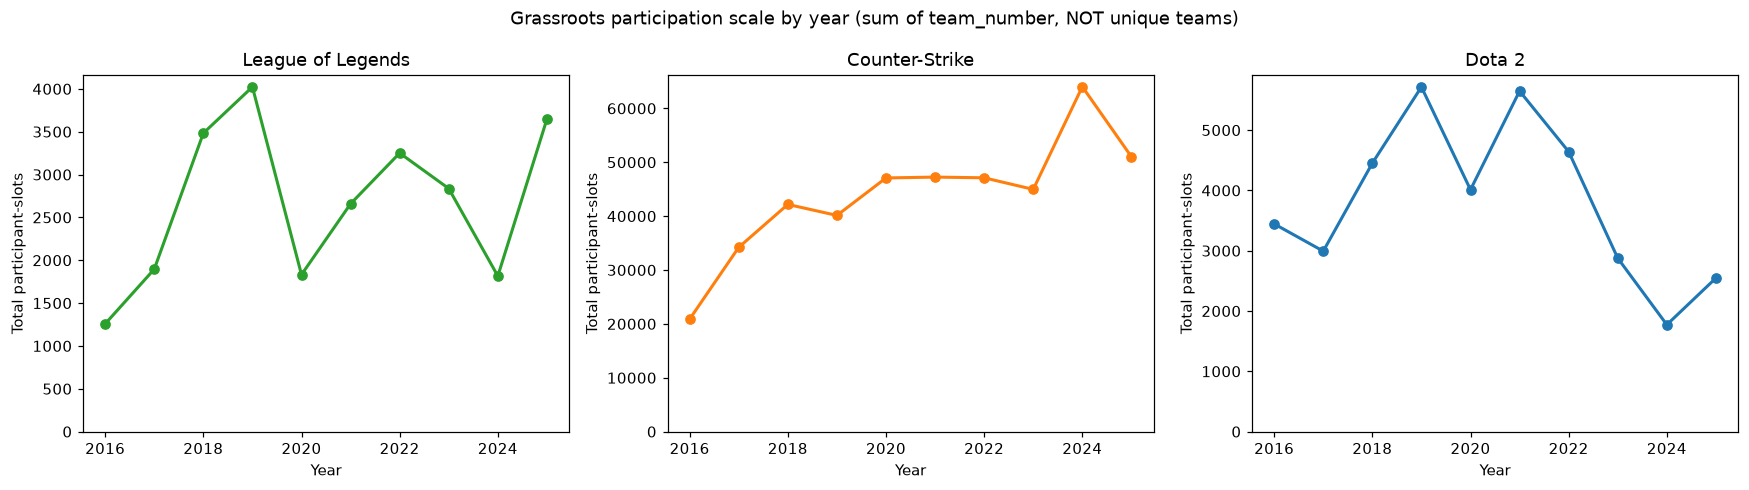


League of Legends:
  yr  slots   n
2016   1258  53
2017   1896  90
2018   3483 193
2019   4023 189
2020   1832 142
2021   2659 176
2022   3251 204
2023   2837 213
2024   1816 152
2025   3647 274

Counter-Strike:
  yr  slots    n
2016  20888  835
2017  34212 1299
2018  42174 1449
2019  40132 1376
2020  47087 1271
2021  47245 1398
2022  47116 1508
2023  44963 1598
2024  64025 1356
2025  51020 1235

Dota 2:
  yr  slots   n
2016   3445 149
2017   2993 173
2018   4452 243
2019   5716 366
2020   4012 295
2021   5648 257
2022   4643 253
2023   2877 239
2024   1773 174
2025   2547 191


In [5]:
def yearly_slots(title_id):
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, sum(team_number) AS slots, count(team_number) AS n "
        f"FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND team_number>=0 "
        f"AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' GROUP BY yr ORDER BY yr",
        conn, params=(title_id,))
    df["yr"] = df["yr"].astype(int)
    return df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]

slots_dfs = {title_id: yearly_slots(title_id) for title_id, _, _ in TITLES}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title_id, color, label) in zip(axes, TITLES):
    df = slots_dfs[title_id]
    ax.plot(df["yr"], df["slots"], "o-", color=color, linewidth=2)
    ax.set_xlabel("Year")
    ax.set_ylabel("Total participant-slots")
    ax.set_title(label)
    ax.set_ylim(bottom=0)
plt.suptitle("Grassroots participation scale by year (sum of team_number, NOT unique teams)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_lol_fig3_slots.png", dpi=110)
plt.show()

for title_id, _, label in TITLES:
    df = slots_dfs[title_id]
    print(f"\n{label}:")
    print(df.to_string(index=False))

**Read**: Counter-Strike's participant-slot scale (~21,000-64,000/year)
dwarfs both League of Legends (~1,800-4,000/year) and Dota 2
(~1,800-5,700/year) by roughly an order of magnitude — consistent with
`grassroots_scene_comparison.ipynb`'s own "mega open-qualifier" finding
(§3 there), not re-investigated in detail here. League of Legends and
Dota 2 are much closer in scale to each other than either is to
Counter-Strike, despite League's higher *tournament count*
(2,485 vs. 3,035 pages) — League's grassroots events are, on average,
somewhat smaller by headcount than Dota 2's. League's slot count shows the
same non-monotonic, still-elevated-not-declining pattern as its tournament
count (1,258 in 2016 → 3,647 in 2025, with a real 2020 dip to 1,832 and a
2024 dip to 1,816) — participation is tracking tournament count reasonably
closely for this title, unlike Counter-Strike's decoupled "fewer events,
similar-or-growing total participation" pattern.

## 5. Region and geography

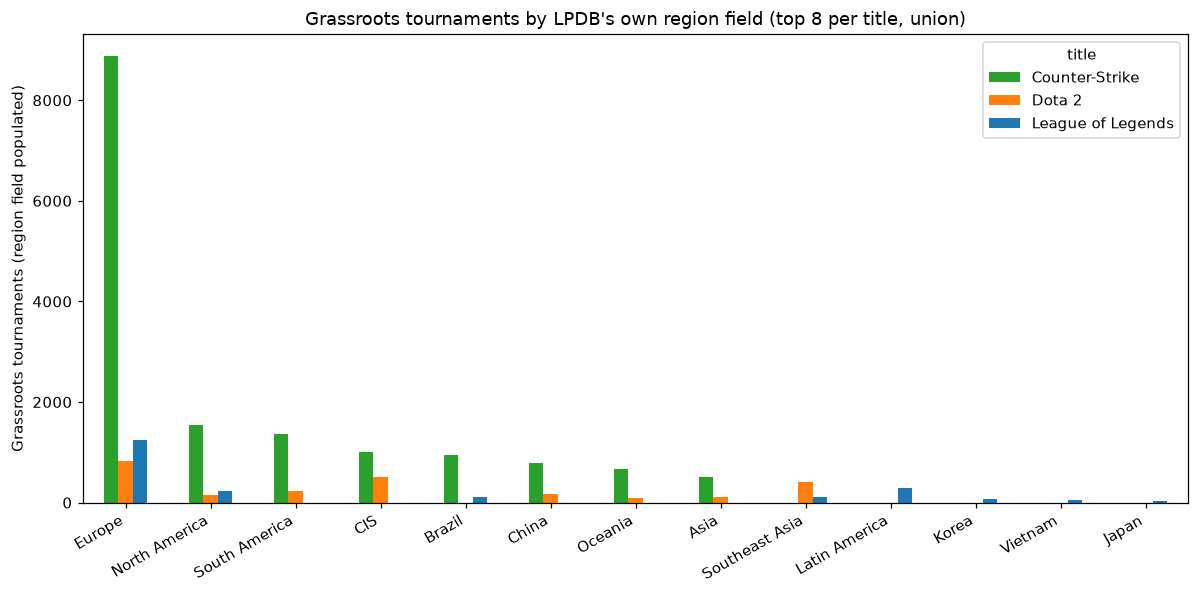


--- Top countries (LPDB's country field -- confirmed clean ISO-2, no broad-region contamination) ---

League of Legends:
country   n
     fr 172
     us 163
     br 119
     de 117
     nl  98
     kr  81
     es  81
     pl  70

Counter-Strike:
country   n
     br 947
     se 942
     cn 792
     pl 494
     de 481
     dk 369
     ru 363
     fr 347

Dota 2:
country   n
     ru 234
     cn 166
     ua  63
     au  58
     br  47
     in  44
     pe  34
     ph  33


In [6]:
region_rows = []
for title_id, _, label in TITLES:
    df = pd.read_sql_query(
        f"SELECT region, count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} "
        f"AND region IS NOT NULL GROUP BY region ORDER BY n DESC LIMIT 8",
        conn, params=(title_id,))
    df["title"] = label
    region_rows.append(df)
region_df = pd.concat(region_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
pivot = region_df.pivot_table(index="region", columns="title", values="n", aggfunc="sum").fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
pivot.plot(kind="bar", ax=ax, color=["#2ca02c", "#ff7f0e", "#1f77b4"])
ax.set_ylabel("Grassroots tournaments (region field populated)")
ax.set_xlabel("")
ax.set_title("Grassroots tournaments by LPDB's own region field (top 8 per title, union)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_lol_fig4_region.png", dpi=110)
plt.show()

print("\n--- Top countries (LPDB's country field -- confirmed clean ISO-2, no broad-region contamination) ---")
for title_id, _, label in TITLES:
    df = pd.read_sql_query(
        f"SELECT country, count(*) AS n FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} "
        f"AND country IS NOT NULL GROUP BY country ORDER BY n DESC LIMIT 8", conn, params=(title_id,))
    print(f"\n{label}:")
    print(df.to_string(index=False))

**Read**: all three titles' grassroots scenes are Europe-led by a wide
margin (League: 1,242 of 2,386 region-tagged rows, 52%; Counter-Strike:
8,871 of 18,156, 49%; Dota 2: 833 of 2,916, 29% — Dota 2 the least
Europe-concentrated of the three). Beyond Europe, the three titles diverge:
League's second tier is Latin America (291) and North America (237), with
Brazil (119), Southeast Asia (103), and Korea (81) also in its top 6 — LPDB's
region scheme breaks out some individual countries as their own "region"
value (Brazil, Korea, China all appear as `region` values here, not just
continents — a quirk of LPDB's own taxonomy, distinct from both
`tournaments.region` and this project's own `COUNTRY_TO_REGION`, per
`schema.sql`'s comment on `tournaments_lpdb.region`). Counter-Strike's
non-Europe tail is more North/South America and CIS-led; Dota 2's is CIS-
and Southeast-Asia-led. At country level, League's top countries (France
172, US 163, Brazil 119, Germany 117, Netherlands 98) look like a genuinely
different geographic footprint from Counter-Strike's (Brazil 947, Sweden
942, China 792) and Dota 2's (Russia 234, China 166, Ukraine 63) — France
and the Netherlands don't appear in either other title's top 8 at all.

## 6. Prize pool over time — nominal only (see §2's currency caveat)

Not currency-filtered, not CPI-deflated (both meaningfully weaker claims
than `grassroots_scene_comparison.ipynb` §6's currency-verified,
CPI-adjusted figures — see §2 above for exactly why). Shown for directional
comparison only; `prize_pool > 0` rows only (§1 found LPDB returns `0`, not
`NULL`, for "no prize").

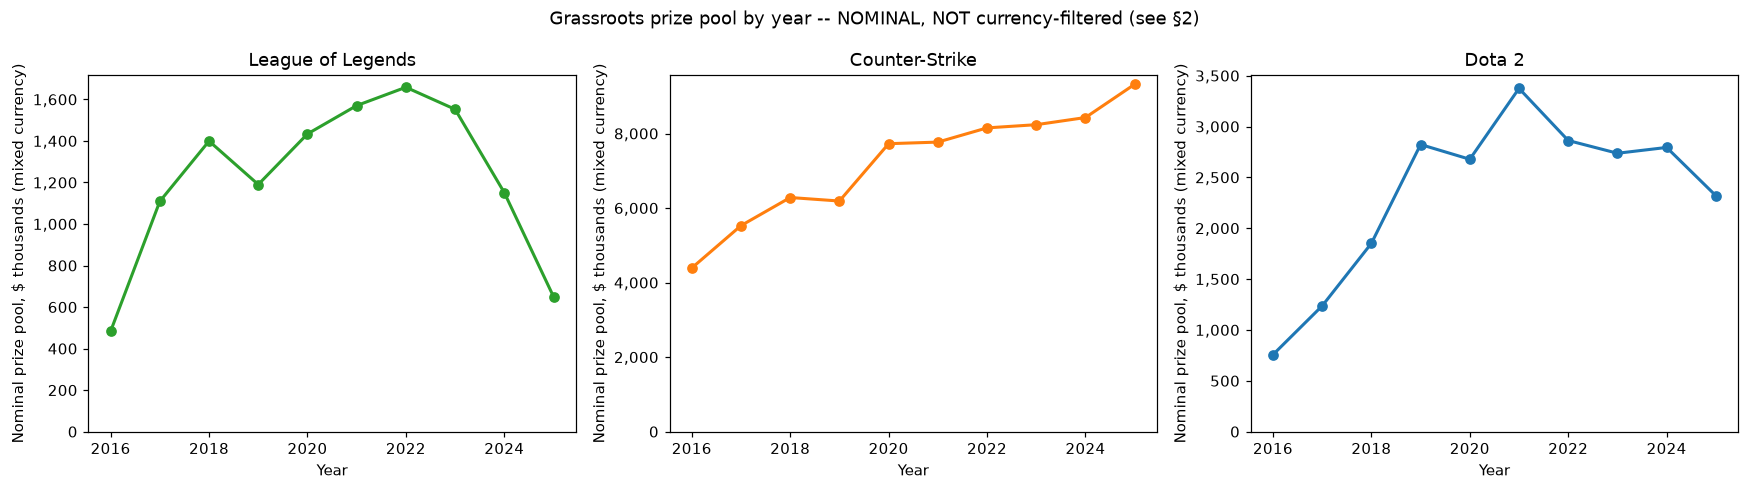


League of Legends:
  yr     total   n  avg_per_event
2016  483654.0  40        12091.0
2017 1109024.0  73        15192.0
2018 1399400.0 105        13328.0
2019 1190120.0 106        11228.0
2020 1433783.0  90        15931.0
2021 1570251.0 123        12766.0
2022 1658457.0 110        15077.0
2023 1552331.0 122        12724.0
2024 1150930.0  86        13383.0
2025  650178.0  98         6634.0

Counter-Strike:
  yr     total    n  avg_per_event
2016 4391165.0  613         7163.0
2017 5528073.0  834         6628.0
2018 6282111.0  829         7578.0
2019 6188020.0  804         7697.0
2020 7726634.0  837         9231.0
2021 7769160.0  849         9151.0
2022 8150741.0 1018         8007.0
2023 8236368.0 1074         7669.0
2024 8428474.0  884         9534.0
2025 9321340.0  750        12428.0

Dota 2:
  yr     total   n  avg_per_event
2016  756356.0 131         5774.0
2017 1236232.0 135         9157.0
2018 1851073.0 184        10060.0
2019 2822863.0 303         9316.0
2020 2677846.0 238       

In [7]:
def yearly_prize(title_id):
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, sum(prize_pool) AS total, count(*) AS n "
        f"FROM tournaments_lpdb WHERE title_id=? AND {GRASSROOTS} AND prize_pool>0 "
        f"AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' GROUP BY yr ORDER BY yr",
        conn, params=(title_id,))
    df["yr"] = df["yr"].astype(int)
    return df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]

prize_dfs = {title_id: yearly_prize(title_id) for title_id, _, _ in TITLES}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title_id, color, label) in zip(axes, TITLES):
    df = prize_dfs[title_id]
    ax.plot(df["yr"], df["total"] / 1000, "o-", color=color, linewidth=2)
    ax.set_xlabel("Year")
    ax.set_ylabel("Nominal prize pool, $ thousands (mixed currency)")
    ax.set_title(label)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.set_ylim(bottom=0)
plt.suptitle("Grassroots prize pool by year -- NOMINAL, NOT currency-filtered (see \xa72)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_lol_fig5_prize.png", dpi=110)
plt.show()

for title_id, _, label in TITLES:
    df = prize_dfs[title_id].copy()
    df["avg_per_event"] = (df["total"] / df["n"]).round(0)
    print(f"\n{label}:")
    print(df.assign(total=df["total"].round(0)).to_string(index=False))

**Read**: Counter-Strike's nominal grassroots prize pool is far larger than
either other title's (\$9.3M in 2025 vs. League's \$650K and Dota 2's
\$2.3M) — consistent with its much larger participant-slot scale (§4). But
**League of Legends' prize-pool trend looks meaningfully different from its
own tournament-count trend**: total nominal prize money peaked in 2022
(\$1.66M) and has since fallen to \$650K by 2025 — even as tournament
*count* kept growing into 2025 (302, its highest year). This is the
opposite pairing from Counter-Strike/Dota 2's own "fewer events, similar-or-
rising money" pattern (`grassroots_scene_comparison.ipynb` §7) — for League,
it's more events but *less* total money, at least in nominal,
currency-unverified terms. Given §2's finding that **zero** of League's
grassroots rows could be cross-checked against a known currency, this
specific divergence should be treated as a flagged pattern worth
independent verification, not a confirmed structural finding — a currency
composition shift (e.g., more events now paying out in a weaker local
currency at face value) could produce exactly this shape without total real
value actually falling. Counter-Strike and Dota 2's own nominal totals here
(Counter-Strike: \$4.4M 2016 → \$9.3M 2025; Dota 2: \$0.76M 2016 → \$2.3M
2025, both rising) are broadly consistent in direction with the original
notebook's CPI-deflated, currency-verified read, even though this pass
doesn't repeat either of those corrections.

## 7. Comparative synthesis

**Scale**: Counter-Strike's grassroots scene remains far and away the
largest of the three by every measure — tournament count (18,196 vs.
League's 2,485 and Dota 2's 3,035), participant-slots (an order of
magnitude above both others), and nominal prize money. League of Legends
sits between Dota 2 and Counter-Strike by tournament count, but closer to
Dota 2 by participation scale — a different profile from either.

**Shape over time — this is the headline difference.** Counter-Strike and
Dota 2 both show the same narrowing-from-a-mid-cycle-peak pattern
`grassroots_scene_comparison.ipynb` already established (Counter-Strike
peaking 2023 under this fuller data, Dota 2 in 2019, both declining since).
**League of Legends does not fit this pattern** — its tournament count grew
from 53 (2016) to 302 (2025), its highest year in the window, with real
volatility but no sustained decline. Whether this reflects a genuinely
different lifecycle stage for League's grassroots scene, or simply that
Liquipedia's own documentation of League grassroots events has itself grown
over time in a way it hasn't for the other two titles' already-mature
grassroots wikis, is not something this data can distinguish — flagged as
the single most important open question this notebook raises, not resolved
by it.

**Geography**: all three titles are Europe-led, but diverge meaningfully
beyond that — League's next-strongest regions are Latin America and North
America with a distinct top-country list (France, US, Brazil, Germany,
Netherlands) that doesn't overlap with Counter-Strike's (Brazil, Sweden,
China) or Dota 2's (Russia, China, Ukraine) top countries at all.

**Prize money tells a genuinely different story for League than for the
other two** — falling nominal totals since a 2022 peak, even as tournament
count keeps growing, the opposite of Counter-Strike/Dota 2's "fewer events,
more money" pattern. Given §2's currency-verification gap is total for
League (zero rows cross-checkable), this is flagged as a real pattern worth
follow-up, not a confirmed finding.

## 8. Bottom line

League of Legends' grassroots tournament scene is real, substantial (2,485
tournaments, 2011-2026), and **structurally invisible to this project before
today** — `tournaments`, the MediaWiki-sourced table, has zero B/C-Tier rows
for this title, because no grassroots crawler was ever built for it. This is
the first comparative read of it against Counter-Strike and Dota 2's
already-established grassroots scenes, made possible entirely by
`collectors/liquipedia_lpdb.py` (Phase 1, 2026-09-30).

The headline finding: **League's grassroots scene looks like it's still
growing (2016-2025), while Counter-Strike's and Dota 2's are both narrowing
from an earlier peak** — a genuine three-way divergence, not just a scale
difference. Geography also diverges beyond the shared Europe-led base — none
of League's top 5 countries appear in either other title's top 5. The one
finding that should NOT be taken as confirmed: League's falling nominal
prize-pool trend, since **zero** of its grassroots rows could be
currency-cross-checked (unlike Counter-Strike's 16%-non-USD and Dota 2's
35%-non-USD matched subsets, which at least bound the risk) — this is the
clearest concrete illustration in this notebook of `docs/
liquipedia_lpdb_transition_plan.md`'s Phase 2 currency-loss finding actually
mattering for a real result, not just a hypothetical caveat.

**Extends `research/esports_lifecycle_and_maturity/brief.md`'s grassroots
work to a third title — written into the brief directly, per its own §15
convention (PRD §15).**